In [93]:
import pandas as pd

from data.data_preprocessing import retrive_and_extract_relevant_data_values, generate_loaders_and_benchmark

In [94]:
df = pd.read_csv(
    "data/OMXS22_raw_features.csv",
    parse_dates=["Date"],
    index_col="Date"
)
start_test_point = df.index[-900*22]
print(start_test_point)
all_tickers = df['Ticker'].unique()
print(all_tickers)


feature_cols = ["Close","Volume",
                "MarketCap","Weight",
                "Return","LogReturn","WeightedRet",
                "SMA20","EMA20","RSI14","ReturnVola20"]

chosen_ticker = "KINV-B.ST"

2021-09-30 00:00:00
['ASSA-B.ST' 'ATCO-A.ST' 'ATCO-B.ST' 'AZN.ST' 'ELUX-B.ST' 'ERIC-B.ST'
 'GETI-B.ST' 'HEXA-B.ST' 'HM-B.ST' 'INVE-B.ST' 'KINV-B.ST' 'NDA-SE.ST'
 'NIBE-B.ST' 'SAAB-B.ST' 'SAND.ST' 'SCA-B.ST' 'SEB-A.ST' 'SHB-A.ST'
 'SKF-B.ST' 'SWED-A.ST' 'TEL2-B.ST' 'VOLV-B.ST']


In [95]:
data_values, dataframe = retrive_and_extract_relevant_data_values(df=df, feature_cols=feature_cols, chosen_ticker=chosen_ticker, no_plotting=True)


Shape dataset (6409, 11)
means:  Close           8.036797e+01
Volume          1.087093e+06
MarketCap       1.954685e+10
Weight          6.289315e-03
Return          4.417263e-04
LogReturn       1.723115e-04
WeightedRet     4.306955e-06
SMA20           8.029539e+01
EMA20           8.029467e+01
RSI14           5.211280e+01
ReturnVola20    2.049862e-02
dtype: float64
stds:  Close           7.186329e+01
Volume          9.459844e+05
MarketCap       1.747837e+10
Weight          3.087590e-03
Return          2.315582e-02
LogReturn       2.325378e-02
WeightedRet     1.423583e-04
SMA20           7.175884e+01
EMA20           7.168856e+01
RSI14           1.325365e+01
ReturnVola20    1.071267e-02
dtype: float64


In [96]:
data_values = data_values
window_step_length = 6
window_size = 50
num_test_points = 900

horizon = 3 #3 is good
target_idx = 0

n_features = data_values.shape[1]

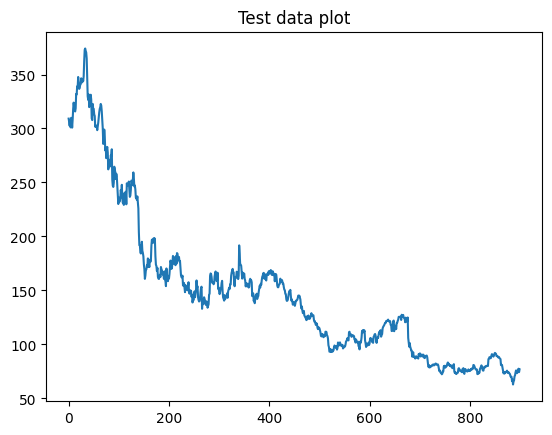

in sequences shape:  (910, 50, 11)
targets shape:  (910, 1)
train loader length:  23
val loader length:  6
Benchmark Celsius: 1.7012497597592897
Normalized Benchmark: 0.026758321859783527


In [97]:
train_loader, val_loader, benchmark = generate_loaders_and_benchmark(raw_numpy_data=data_values, 
                                                                     window_step_length=window_step_length,
                                                                     window_size=window_size,
                                                                     num_test_points=num_test_points,
                                                                     horizon=horizon,
                                                                     target_idx=target_idx,
                                                                     minimal_plotting=False
                                                                     )

In [98]:
from train.train_functions import get_device, plot_training, test_model_output
from single_asset_models.CrossAttentionGRUV1 import CrossAttentionGRUV1
from single_asset_models.CrossAttentionGRUV2 import CrossAttentionGRUV2

import deeplay as dl
import torch

In [7]:
device = get_device()
print(device)

mps


In [8]:
cross_attn_gru_v1 = CrossAttentionGRUV1(in_dim=n_features, hidden_dim=144, num_hidden_layers=3, out_dim=1, dropout=0.1, num_heads=24)
cross_attn_gru_v2 = CrossAttentionGRUV2(in_dim=n_features, hidden_dim=144, num_hidden_layers=3, out_dim=1, dropout=0.1, num_heads=24)

In [9]:
gru_dl = dl.RecurrentModel(
    in_features=n_features,
    hidden_features=[128, 128, 128],
    out_features=1,
    rnn_type="GRU",
    dropout=0.2,
)

In [10]:
epochs = 40

In [52]:
chosen_model = cross_attn_gru_v1
print(type(chosen_model))

<class 'single_asset_models.CrossAttentionGRUV1.CrossAttentionGRUV1'>


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss              │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection    │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection    │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection    │      0 │ train │
│ 4 │ model         │ CrossAttentionGRUV1 │  445 K │ train │
│ 5 │ optimizer     │ Adam                │      0 │ train │
└───┴───────────────┴─────────────────────┴────────┴───────┘

Trainable params: 445 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 445 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (23) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

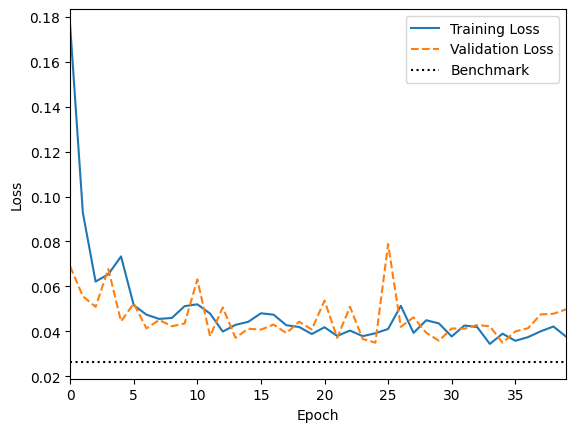

In [53]:
#trained_chosen_model_path = train_model(chosen_model, epochs=epochs, optimizer=, train_loader=train_loader, val_loader=val_loader, benchmark=benchmark)

chosen_model_reg = dl.Regressor(chosen_model, optimizer=dl.Adam(lr=0.001)).create()

trainer = dl.Trainer(max_epochs=epochs, accelerator="auto")
trainer.fit(chosen_model_reg, train_loader, val_loader)
train_losses = trainer.history.history["train_loss_epoch"]["value"]
val_losses = trainer.history.history["val_loss_epoch"]["value"][1:]
plot_training(epochs, train_losses, val_losses, benchmark)

In [54]:
test_model_output(model=chosen_model_reg, data_loader=val_loader, num_tests=10)

Last 10 timesteps (input) and true vs predicted temperature:
Sample 1: Last input temp = 0.35, True = -0.75, Pred = -0.75
Sample 2: Last input temp = -0.69, True = -0.92, Pred = -0.94
Sample 3: Last input temp = 0.27, True = -0.17, Pred = -0.15
Sample 4: Last input temp = -0.48, True = 0.65, Pred = 0.75
Sample 5: Last input temp = -0.67, True = -0.68, Pred = -0.71
Sample 6: Last input temp = 0.09, True = -0.68, Pred = -0.72
Sample 7: Last input temp = -0.09, True = -0.83, Pred = -0.86
Sample 8: Last input temp = -0.44, True = 1.05, Pred = 1.10
Sample 9: Last input temp = 0.87, True = -0.55, Pred = -0.55
Sample 10: Last input temp = -0.60, True = 0.94, Pred = 1.04


variance of returns for old data:  0.0015558192717572451
start window shape:  torch.Size([6, 11])
test data shape torch.Size([900, 11])


/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


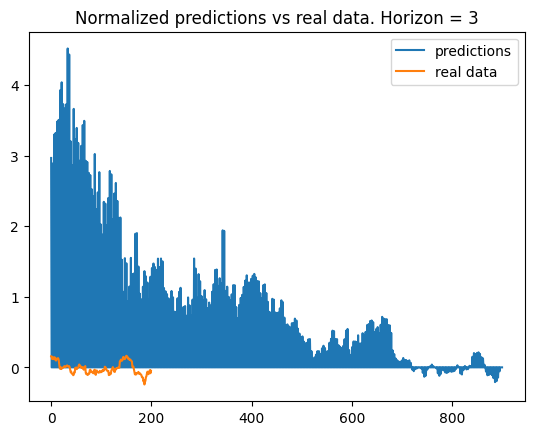

In [57]:
from model_inference.inference_functions import generate_predictions_and_returns, plot_pred_vs_real

predictions_normalized, test_weights, test_pnl = generate_predictions_and_returns(chosen_model_reg, window_step_length, data_values, target_idx, num_of_future_predictions=num_test_points, horizon=horizon)

plot_pred_vs_real(predictions_normalized, data_values, target_idx, horizon, minimal_plotting=True)

3
variance of returns for old data:  0.0015558192717572451
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(305.1500)
period from idx:  0  to idx  3
prediction at 3:  tensor(321.5646)
last price from test data:  305.1499938964844
real price 3 steps forward:  tensor(308.1000)
kelly weight:  {tensor(1., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(302.5000)
period from idx:  3  to idx  6
prediction at 3:  tensor(312.5987)
last price from test data:  tensor(302.5000)
real price 3 steps forward:  tensor(308.2000)
kelly weight:  {tensor(1., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(309.9000)
period from idx:  6  to idx  9
prediction at 3:  tensor(325.7504)
last price from test data:  tensor(309.9000)
real price 3 steps forward:  tensor(318.0500)
kelly weight:  {tensor(1., dtype=torch.float64)}
 
x_in shape:

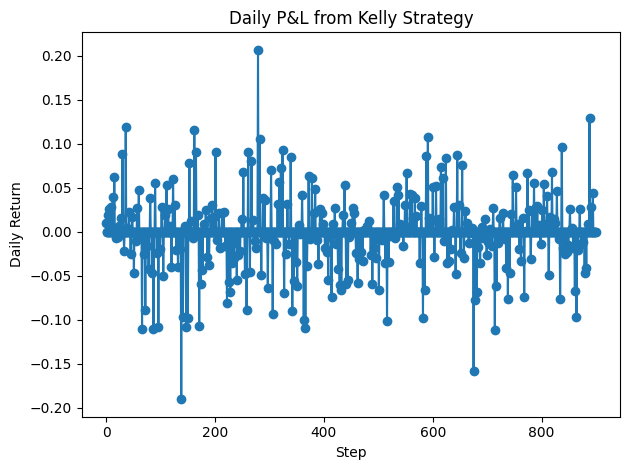

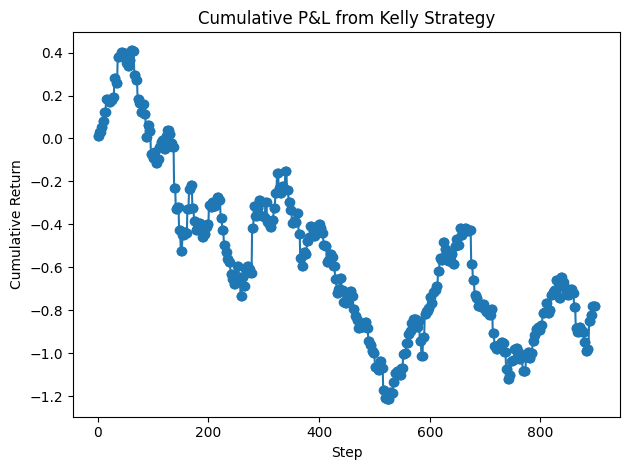

In [58]:
from model_inference.inference_functions import  generate_predictions_and_returns, plot_realized_returns
import matplotlib.pyplot as plt
import numpy as np

print(horizon)
preds_norm, weights, pnl = generate_predictions_and_returns(chosen_model_reg, 
                                                  window_size, 
                                                  data_values, 
                                                  target_idx,
                                                  num_of_future_predictions=num_test_points, 
                                                  horizon=horizon,
                                                  print_values_for_allocation=True)

plot_realized_returns(pnl, plot_only_cumulative=False)

In [59]:
print(weights)
print()
print(pnl)

'''Model version_61 had 0.02 in mae'''

[ 1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
 -1.          0.          0.         -1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.          0.          1.          0.          0.
  1.          0.         

'Model version_61 had 0.02 in mae'

Shape dataset (6409, 11)
means:  Close           8.057271e+01
Volume          1.259072e+07
MarketCap       1.279897e+11
Weight          4.173304e-02
Return          6.364129e-04
LogReturn       4.338309e-04
WeightedRet     3.053555e-05
SMA20           8.022321e+01
EMA20           8.021005e+01
RSI14           5.253680e+01
ReturnVola20    1.835859e-02
dtype: float64
stds:  Close           6.781238e+01
Volume          1.708028e+07
MarketCap       1.077200e+11
Weight          1.297622e-02
Return          2.013867e-02
LogReturn       2.012149e-02
WeightedRet     8.541972e-04
SMA20           6.744902e+01
EMA20           6.737596e+01
RSI14           1.213508e+01
ReturnVola20    8.307794e-03
dtype: float64


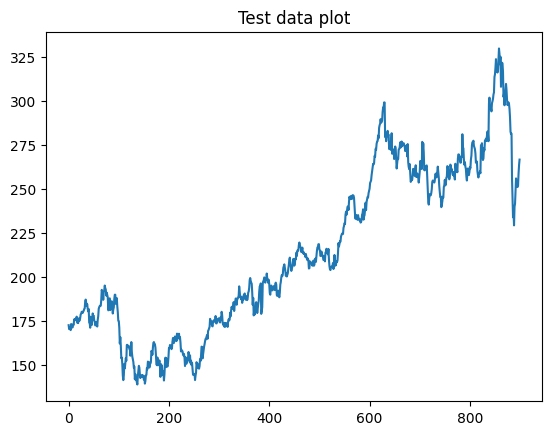

in sequences shape:  (910, 50, 11)
targets shape:  (910, 1)
train loader length:  23
val loader length:  6
Benchmark Celsius: 1.4331503520651032
Normalized Benchmark: 0.03580219319925751


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss              │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection    │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection    │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection    │      0 │ train │
│ 4 │ model         │ CrossAttentionGRUV1 │  445 K │ train │
│ 5 │ optimizer     │ Adam                │      0 │ train │
└───┴───────────────┴─────────────────────┴────────┴───────┘

Trainable params: 445 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 445 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (23) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

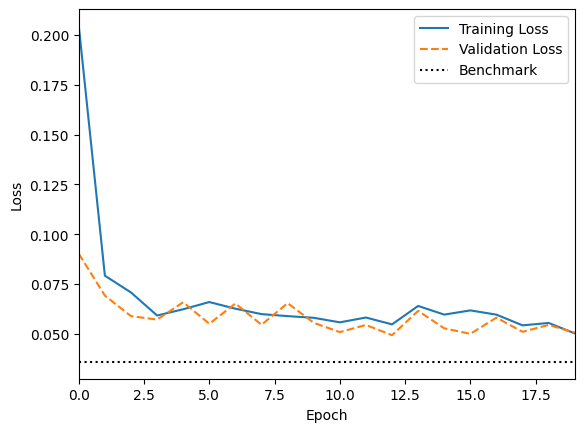

variance of returns for old data:  0.001323928669998616
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(170.9581)
period from idx:  0  to idx  3
prediction at 3:  tensor(174.4420)
last price from test data:  170.9580535888672
real price 3 steps forward:  tensor(171.3435)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(171.0456)
period from idx:  3  to idx  6
prediction at 3:  tensor(173.1111)
last price from test data:  tensor(171.0456)
real price 3 steps forward:  tensor(172.5523)
kelly weight:  {tensor(9.1211, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(173.3057)
period from idx:  6  to idx  9
prediction at 3:  tensor(174.8659)
last price from test data:  tensor(173.3057)
real price 3 steps forward:  tensor(173.0779)
kelly weight:  {tensor(6.8000, dtype=torch.float64)}
 
x_in 

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(175.8986)
period from idx:  48  to idx  51
prediction at 3:  tensor(175.4922)
last price from test data:  tensor(175.8986)
real price 3 steps forward:  tensor(175.2854)
kelly weight:  {tensor(-1.7451, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(177.9572)
period from idx:  51  to idx  54
prediction at 3:  tensor(179.7186)
last price from test data:  tensor(177.9572)
real price 3 steps forward:  tensor(172.5699)
kelly weight:  {tensor(7.4762, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(172.4998)
period from idx:  54  to idx  57
prediction at 3:  tensor(173.5280)
last price from test data:  tensor(172.4998)
real price 3 steps forward:  tensor(171.8691)
kelly weight:  {tensor(4.5021, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(173.6210)
period from idx:  57  to idx  60
prediction at 3:  tensor

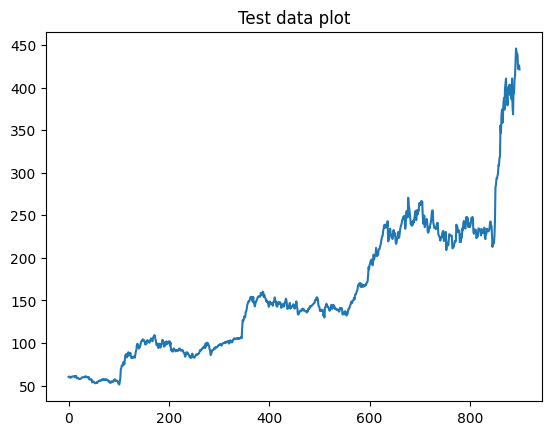

in sequences shape:  (910, 50, 11)
targets shape:  (910, 1)
train loader length:  23
val loader length:  6
Benchmark Celsius: 0.7906823980994455
Normalized Benchmark: 0.03530749668307227


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss              │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection    │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection    │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection    │      0 │ train │
│ 4 │ model         │ CrossAttentionGRUV1 │  445 K │ train │
│ 5 │ optimizer     │ Adam                │      0 │ train │
└───┴───────────────┴─────────────────────┴────────┴───────┘

Trainable params: 445 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 445 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (23) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

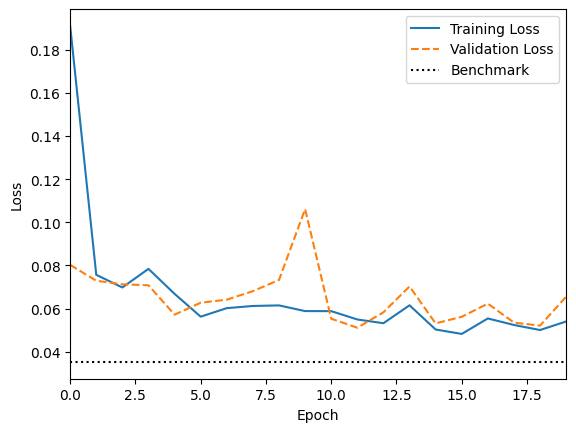

variance of returns for old data:  0.0011896883152951584
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(60.6015)
period from idx:  0  to idx  3
prediction at 3:  tensor(60.6328)
last price from test data:  60.60148620605469
real price 3 steps forward:  tensor(59.3183)
kelly weight:  {tensor(0.4346, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(59.7783)
period from idx:  3  to idx  6
prediction at 3:  tensor(59.8278)
last price from test data:  tensor(59.7783)
real price 3 steps forward:  tensor(60.1657)
kelly weight:  {tensor(0.6967, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(60.1173)
period from idx:  6  to idx  9
prediction at 3:  tensor(59.6204)
last price from test data:  tensor(60.1173)
real price 3 steps forward:  tensor(60.7468)
kelly weight:  {tensor(-6.9473, dtype=torch.float64)}
 
x_in shape:

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(57.2119)
period from idx:  42  to idx  45
prediction at 3:  tensor(57.0612)
last price from test data:  tensor(57.2119)
real price 3 steps forward:  tensor(57.3329)
kelly weight:  {tensor(-2.2136, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(57.7203)
period from idx:  45  to idx  48
prediction at 3:  tensor(56.0369)
last price from test data:  tensor(57.7203)
real price 3 steps forward:  tensor(55.0328)
kelly weight:  {tensor(-15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(53.6770)
period from idx:  48  to idx  51
prediction at 3:  tensor(50.2727)
last price from test data:  tensor(53.6770)
real price 3 steps forward:  tensor(54.0159)
kelly weight:  {tensor(-15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(54.5486)
period from idx:  51  to idx  54
prediction at 3:  tensor(50.1172)
last pr

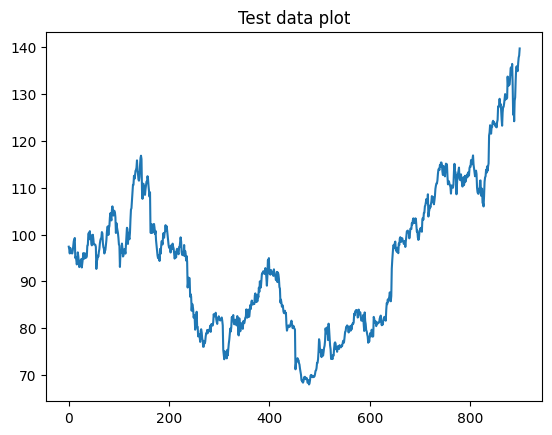

in sequences shape:  (910, 50, 11)
targets shape:  (910, 1)
train loader length:  23
val loader length:  6
Benchmark Celsius: 1.0720327812413757
Normalized Benchmark: 0.05392735841877777


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss              │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection    │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection    │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection    │      0 │ train │
│ 4 │ model         │ CrossAttentionGRUV1 │  445 K │ train │
│ 5 │ optimizer     │ Adam                │      0 │ train │
└───┴───────────────┴─────────────────────┴────────┴───────┘

Trainable params: 445 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 445 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (23) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

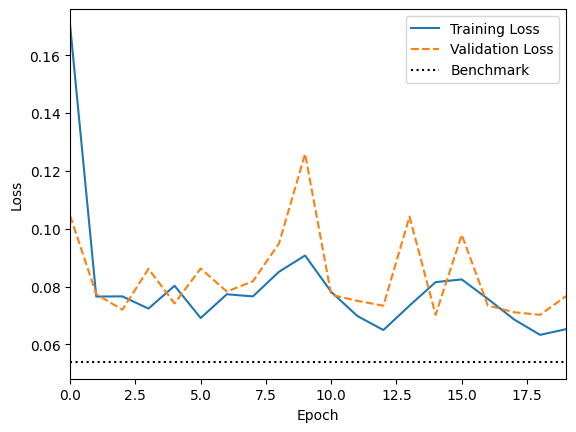

variance of returns for old data:  0.001367076860959911
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(95.9744)
period from idx:  0  to idx  3
prediction at 3:  tensor(96.4916)
last price from test data:  95.974365234375
real price 3 steps forward:  tensor(97.1441)
kelly weight:  {tensor(3.9425, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(95.9538)
period from idx:  3  to idx  6
prediction at 3:  tensor(96.7164)
last price from test data:  tensor(95.9538)
real price 3 steps forward:  tensor(95.9922)
kelly weight:  {tensor(5.8131, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(96.4146)
period from idx:  6  to idx  9
prediction at 3:  tensor(97.1688)
last price from test data:  tensor(96.4146)
real price 3 steps forward:  tensor(97.6433)
kelly weight:  {tensor(5.7217, dtype=torch.float64)}
 
x_in shape:  to

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(97.8737)
period from idx:  51  to idx  54
prediction at 3:  tensor(98.1906)
last price from test data:  tensor(97.8737)
real price 3 steps forward:  tensor(97.3361)
kelly weight:  {tensor(2.3681, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(97.7969)
period from idx:  54  to idx  57
prediction at 3:  tensor(98.2337)
last price from test data:  tensor(97.7969)
real price 3 steps forward:  tensor(94.6867)
kelly weight:  {tensor(3.2670, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(94.3028)
period from idx:  57  to idx  60
prediction at 3:  tensor(94.1087)
last price from test data:  tensor(94.3028)
real price 3 steps forward:  tensor(96.2994)
kelly weight:  {tensor(-1.5057, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(95.2627)
period from idx:  60  to idx  63
prediction at 3:  tensor(95.1649)
las

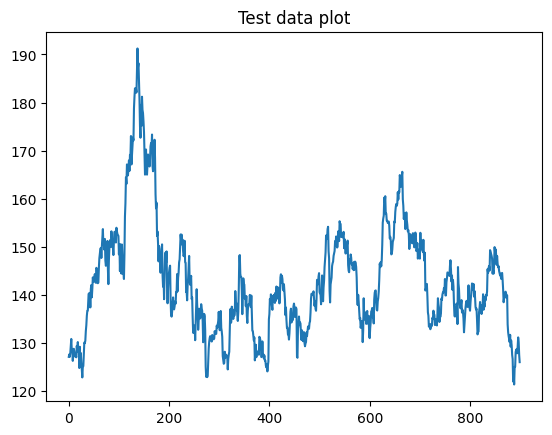

in sequences shape:  (910, 50, 11)
targets shape:  (910, 1)
train loader length:  23
val loader length:  6
Benchmark Celsius: 0.5466233542560448
Normalized Benchmark: 0.015367760129081327


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss              │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection    │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection    │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection    │      0 │ train │
│ 4 │ model         │ CrossAttentionGRUV1 │  445 K │ train │
│ 5 │ optimizer     │ Adam                │      0 │ train │
└───┴───────────────┴─────────────────────┴────────┴───────┘

Trainable params: 445 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 445 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (23) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

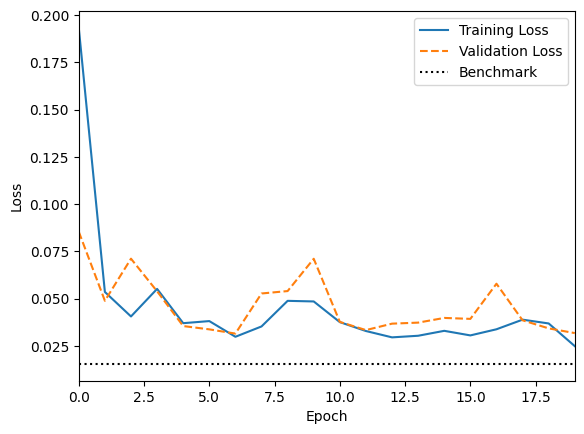

variance of returns for old data:  0.0010743030419021718
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(126.4020)
period from idx:  0  to idx  3
prediction at 3:  tensor(126.8456)
last price from test data:  126.4019546508789
real price 3 steps forward:  tensor(127.7992)
kelly weight:  {tensor(3.2667, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(127.0540)
period from idx:  3  to idx  6
prediction at 3:  tensor(126.5297)
last price from test data:  tensor(127.0540)
real price 3 steps forward:  tensor(128.5444)
kelly weight:  {tensor(-3.8410, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(130.7799)
period from idx:  6  to idx  9
prediction at 3:  tensor(129.6953)
last price from test data:  tensor(130.7799)
real price 3 steps forward:  tensor(127.7060)
kelly weight:  {tensor(-7.7197, dtype=torch.float64)}
 

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(142.6097)
period from idx:  54  to idx  57
prediction at 3:  tensor(139.3941)
last price from test data:  tensor(142.6097)
real price 3 steps forward:  tensor(142.4700)
kelly weight:  {tensor(-15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(145.3576)
period from idx:  57  to idx  60
prediction at 3:  tensor(141.8875)
last price from test data:  tensor(145.3576)
real price 3 steps forward:  tensor(145.5439)
kelly weight:  {tensor(-15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(142.5166)
period from idx:  60  to idx  63
prediction at 3:  tensor(138.7655)
last price from test data:  tensor(142.5166)
real price 3 steps forward:  tensor(149.5027)
kelly weight:  {tensor(-15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(148.6644)
period from idx:  63  to idx  66
prediction at 3:  tensor(145.09

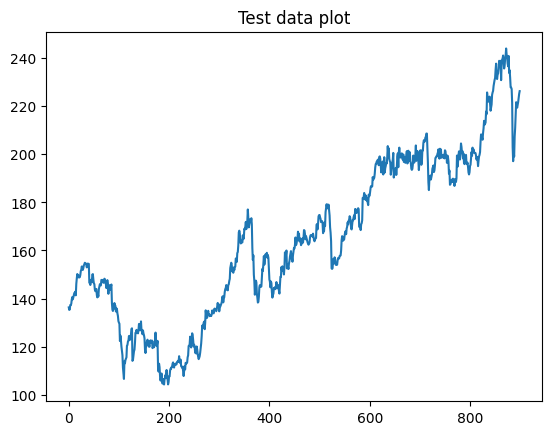

in sequences shape:  (910, 50, 11)
targets shape:  (910, 1)
train loader length:  23
val loader length:  6
Benchmark Celsius: 1.3616151598380601
Normalized Benchmark: 0.03741298864405384


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss              │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection    │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection    │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection    │      0 │ train │
│ 4 │ model         │ CrossAttentionGRUV1 │  445 K │ train │
│ 5 │ optimizer     │ Adam                │      0 │ train │
└───┴───────────────┴─────────────────────┴────────┴───────┘

Trainable params: 445 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 445 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (23) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

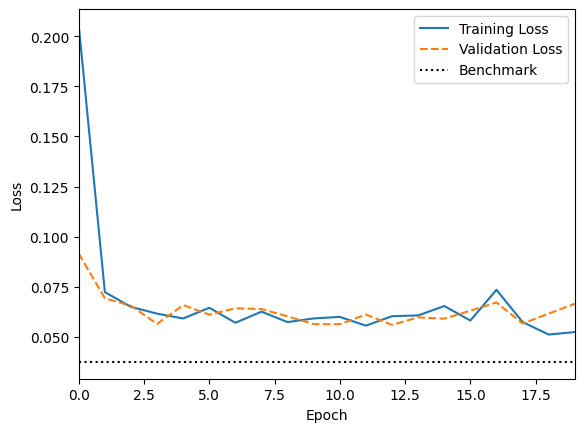

variance of returns for old data:  0.0013601234664937121
start window shape:  torch.Size([50, 11])
test data shape torch.Size([900, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(135.3259)
period from idx:  0  to idx  3
prediction at 3:  tensor(140.7263)
last price from test data:  135.32594299316406
real price 3 steps forward:  tensor(137.2785)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(135.4643)
period from idx:  3  to idx  6
prediction at 3:  tensor(140.3596)
last price from test data:  tensor(135.4643)
real price 3 steps forward:  tensor(139.5847)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(137.8320)
period from idx:  6  to idx  9
prediction at 3:  tensor(142.9531)
last price from test data:  tensor(137.8320)
real price 3 steps forward:  tensor(140.3534)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shap

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:266: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:268: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(146.3378)
period from idx:  51  to idx  54
prediction at 3:  tensor(152.2279)
last price from test data:  tensor(146.3378)
real price 3 steps forward:  tensor(143.6701)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(143.0311)
period from idx:  54  to idx  57
prediction at 3:  tensor(148.0864)
last price from test data:  tensor(143.0311)
real price 3 steps forward:  tensor(140.4593)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(141.3699)
period from idx:  57  to idx  60
prediction at 3:  tensor(146.0043)
last price from test data:  tensor(141.3699)
real price 3 steps forward:  tensor(143.9257)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(140.8587)
period from idx:  60  to idx  63
prediction at 3:  tensor(144.2121)

In [157]:
from model_inference.inference_functions import generate_weights_from_predictions
tickers = ['VOLV-B.ST', 'SAAB-B.ST', 'TEL2-B.ST', 'SCA-B.ST', 'SWED-A.ST']
all_weights = []
#tickers = all_tickers
#tickers = ['TEL2-B.ST']
epochs = 20
for ticker in tickers:
    data_values, dataframe = retrive_and_extract_relevant_data_values(df=df, feature_cols=feature_cols, chosen_ticker=ticker, no_plotting=True)

    train_loader, val_loader, benchmark = generate_loaders_and_benchmark(raw_numpy_data=data_values, 
                                                                     window_step_length=window_step_length,
                                                                     window_size=window_size,
                                                                     num_test_points=num_test_points,
                                                                     horizon=horizon,
                                                                     target_idx=target_idx,
                                                                     minimal_plotting=False
                                                                     )
    cross_attn_gru_v2 = CrossAttentionGRUV1(in_dim=n_features, hidden_dim=144, num_hidden_layers=3, out_dim=1, dropout=0.1, num_heads=24)
    #trained_chosen_model_path = train_model(chosen_model, epochs=epochs, optimizer=, train_loader=train_loader, val_loader=val_loader, benchmark=benchmark)
    chosen_model = cross_attn_gru_v2
    chosen_model_reg = dl.Regressor(chosen_model, optimizer=dl.Adam(lr=0.001)).create()

    trainer = dl.Trainer(max_epochs=epochs, accelerator="auto")
    trainer.fit(chosen_model_reg, train_loader, val_loader)
    train_losses = trainer.history.history["train_loss_epoch"]["value"]
    val_losses = trainer.history.history["val_loss_epoch"]["value"][1:]
    plot_training(epochs, train_losses, val_losses, benchmark)
    preds_norm, weights = generate_weights_from_predictions(chosen_model_reg, 
                                                  window_size, 
                                                  data_values, 
                                                  target_idx,
                                                  num_of_future_predictions=num_test_points, 
                                                  horizon=horizon,
                                                  kelly_clip=15,
                                                  print_values_for_allocation=True)
    all_weights.append(weights)
    

    #plot_realized_returns(pnl, plot_only_cumulative=True)

In [158]:
import numpy as np
print(np.array(all_weights).shape)

(5, 300)


[[ 0.033       0.0200664   0.0149599  ...  0.033       0.033
   0.        ]
 [ 0.00095614  0.00153267 -0.01528416 ... -0.033      -0.033
   0.        ]
 [ 0.0086735   0.01278885  0.01258766 ... -0.03219019 -0.033
   0.        ]
 [ 0.00718683 -0.0084501  -0.01698331 ... -0.01425688 -0.02572573
   0.        ]
 [ 0.033       0.033       0.033      ...  0.033       0.033
   0.        ]]
[[15.          9.12108898  6.79995346 ... 15.         15.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 3.94249892  5.81311464  5.72166157 ...  0.          0.
   0.        ]
 [ 3.26673865  0.          0.         ...  0.          0.
   0.        ]
 [15.         15.         15.         ... 15.         15.
   0.        ]]
(5, 900)
(900,)
900


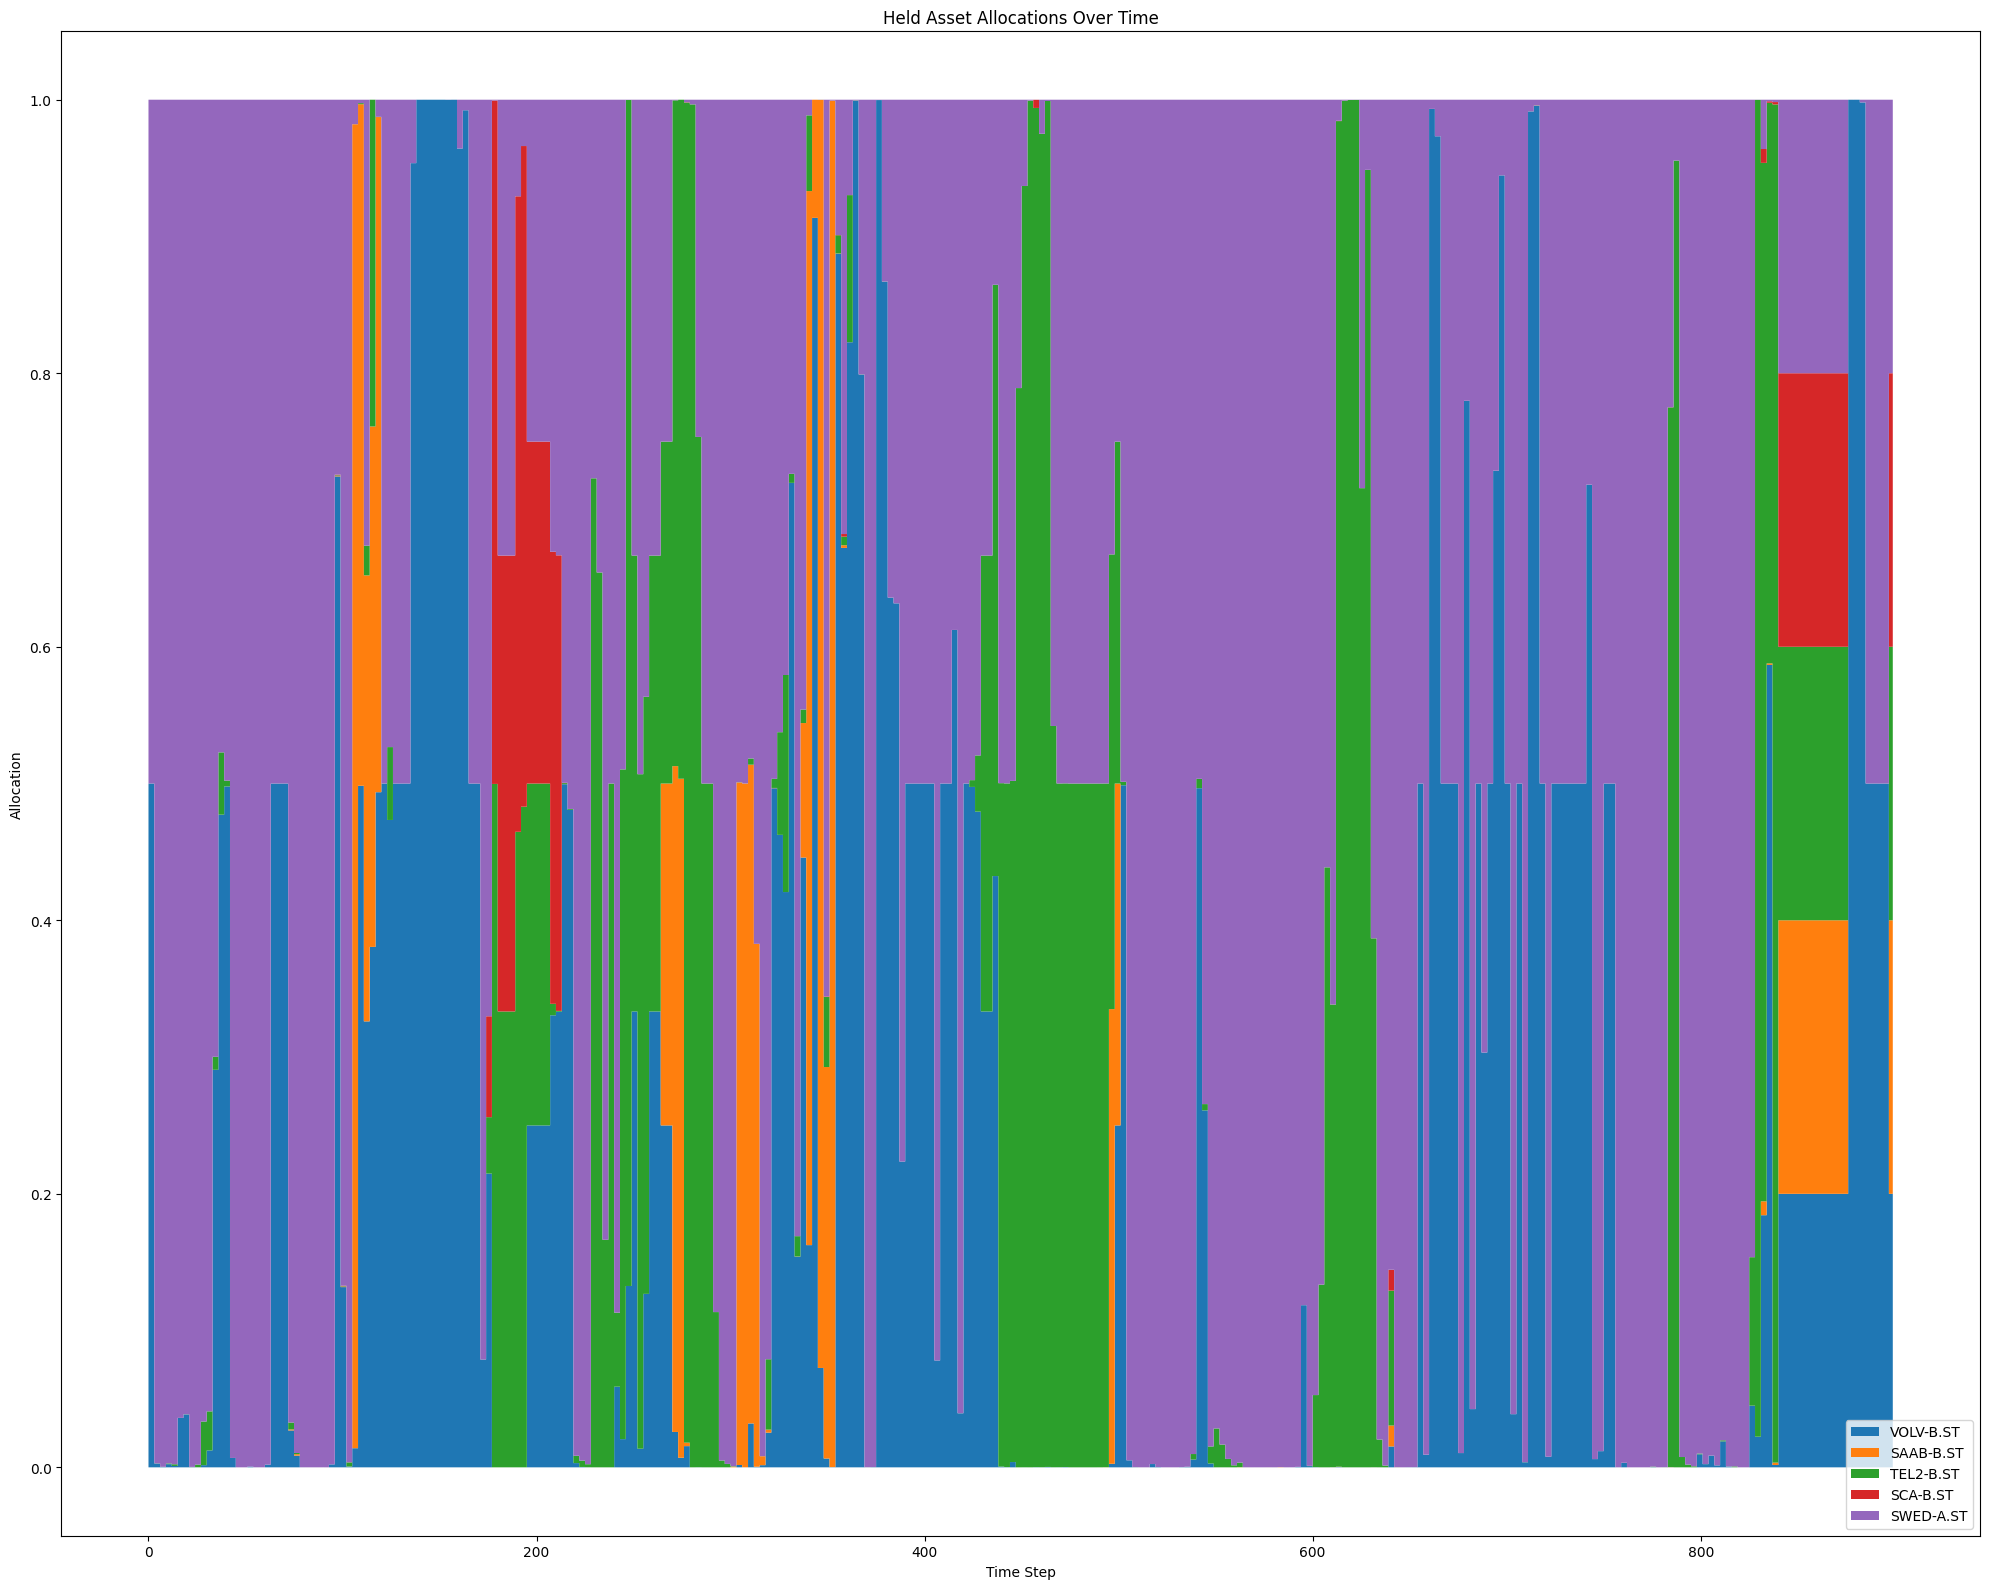

In [159]:
lowball_variance = 0.0022
trading_cost = 0.005

lowball_returns = all_weights*np.array([lowball_variance])
print(lowball_returns)

trading_cost_adjusted_returns = np.where(lowball_returns < trading_cost, lowball_returns - lowball_returns, lowball_returns)
trading_cost_adjusted_weights = trading_cost_adjusted_returns / lowball_variance
print(trading_cost_adjusted_weights)


from allocation_functions.allocation_functions import allocate_from_weights, plot_allocations

alloc = allocate_from_weights(all_weights, horizon=horizon, num_of_test_points=num_test_points)
print(alloc.shape)
alloc_diff = np.diff(alloc, axis=1)
alloc_diff = np.concatenate([alloc_diff, np.zeros((len(tickers),1))], axis=1)
alloc_diff = 0.5* np.sum(np.abs(alloc_diff), axis=0)
print(alloc_diff.shape)

def plot_allocations(alloc, tickers):
    n_assets, total_steps = alloc.shape
    print(total_steps)
    
    

    # Time axis
    t = np.arange(total_steps)

    # Compute cumulative allocations for stacking
    cumsum = np.cumsum(alloc, axis=0)

    plt.figure(figsize=(20,16))
    # Plot filled areas for each asset
    for i in range(n_assets):
        bottom = cumsum[i-1] if i > 0 else np.zeros_like(t)
        top = cumsum[i]
        plt.fill_between(t, bottom, top, step='post', label=tickers[i])
    
    plt.xlabel('Time Step')
    plt.ylabel('Allocation')
    plt.title('Held Asset Allocations Over Time')
    plt.legend()
    plt.tight_layout()
    plt.show()
plot_allocations(alloc, tickers)

(5, 900)
(5, 900)
[[0.04545455 0.04545455 0.04545455 ... 0.04545455 0.04545455 0.04545455]
 [0.04545455 0.04545455 0.04545455 ... 0.04545455 0.04545455 0.04545455]
 [0.04545455 0.04545455 0.04545455 ... 0.04545455 0.04545455 0.04545455]
 ...
 [0.04545455 0.04545455 0.04545455 ... 0.04545455 0.04545455 0.04545455]
 [0.04545455 0.04545455 0.04545455 ... 0.04545455 0.04545455 0.04545455]
 [0.04545455 0.04545455 0.04545455 ... 0.04545455 0.04545455 0.04545455]]
(900,)
[ 7.67470190e-04  0.00000000e+00 -2.48603952e-03  1.74648015e-02
  0.00000000e+00 -1.26209457e-05  1.31546862e-02  0.00000000e+00
 -1.24352967e-05  1.87367054e-02  0.00000000e+00 -6.50741044e-06
 -6.62257158e-03  0.00000000e+00 -1.75441739e-04  6.00623781e-02
  0.00000000e+00 -1.32016569e-05 -3.79417241e-03  0.00000000e+00
 -1.92649449e-04  1.60273425e-03  0.00000000e+00 -8.88508630e-06
  2.39230677e-02  0.00000000e+00 -1.57492050e-04 -3.67529160e-03
  0.00000000e+00 -5.38584119e-05  1.43554388e-02  0.00000000e+00
 -1.3915533

Text(0, 0.5, 'Returns')

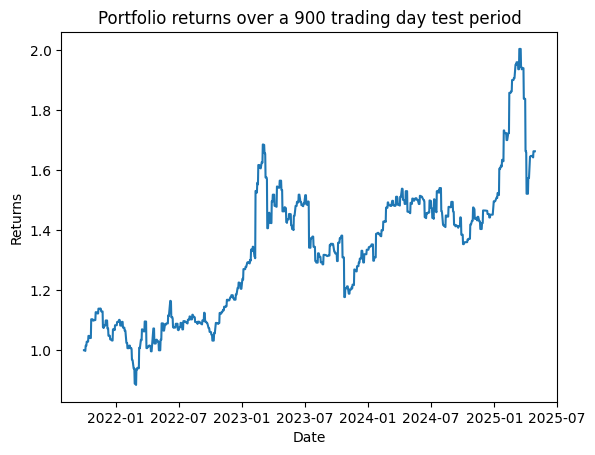

In [160]:
from allocation_functions.allocation_functions import calculate_asset_returns, calculate_portfolio_returns, calculate_cumulative_portfolio_returns, retrieve_test_closing_price
import matplotlib.pyplot as plt
returns = calculate_asset_returns(df, tickers, horizon, num_of_test_points=num_test_points)
print(alloc.shape)
print(returns.shape)
test_alloc = np.ones((22,900))/22
print(test_alloc)
portfolio_returns = calculate_portfolio_returns(alloc, returns)
print(portfolio_returns.shape)

portfolio_returns_with_tradingcost = np.where(portfolio_returns > 0, portfolio_returns - alloc_diff*trading_cost, portfolio_returns)
portfolio_returns_with_tradingcost = portfolio_returns - alloc_diff*trading_cost
print(portfolio_returns_with_tradingcost)
portfolio_cum_return = calculate_cumulative_portfolio_returns(portfolio_returns_with_tradingcost)
print(portfolio_cum_return)

test_indices = df.index[-900*22::22]
plt.plot(test_indices, portfolio_cum_return, label='portfolio returns')
plt.title('Portfolio returns over a 900 trading day test period')
plt.xlabel('Date')
plt.ylabel('Returns')


DatetimeIndex(['2021-09-30', '2021-10-01', '2021-10-04', '2021-10-05',
               '2021-10-06', '2021-10-07', '2021-10-08', '2021-10-11',
               '2021-10-12', '2021-10-13',
               ...
               '2025-04-11', '2025-04-14', '2025-04-15', '2025-04-16',
               '2025-04-17', '2025-04-22', '2025-04-23', '2025-04-24',
               '2025-04-25', '2025-04-28'],
              dtype='datetime64[ns]', name='Date', length=900, freq=None)
900
[11.39686355 11.31727194 11.25258812 11.36665288 11.23263317 11.40652557
 11.34813842 11.35384295 11.38108738 11.45051825 11.49800513 11.56505374
 11.53769329 11.57945076 11.59120165 11.63124022 11.77759597 11.70838981
 11.75319871 11.658384   11.68941887 11.644011   11.68435121 11.81727048
 11.8812165  11.94160694 11.93147759 11.97607684 11.92679618 11.99107053
 12.04764797 11.94289721 12.05022273 11.97096225 12.02610682 11.87906998
 11.92520939 11.91413458 11.8213404  11.8605612  11.94295874 11.56286478
 11.67372922 11.53715

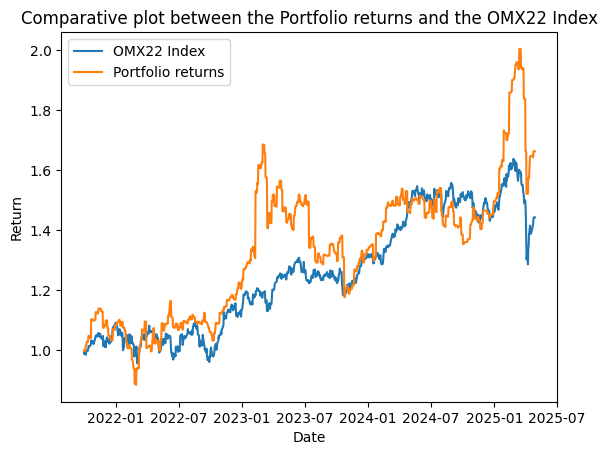

In [161]:

df_omx22 = pd.read_csv(
    "data/MCAP_22_Index_raw.csv",
    parse_dates=["Date"],
    index_col="Date"
)


print(test_indices)

index_test_values = df_omx22['MCAP_22_Index'].iloc[-num_test_points:].values
print(len(index_test_values))
print(index_test_values)
index_diffs = np.diff(index_test_values, axis=0)
index_diffs = np.concatenate([index_diffs, np.zeros((1))], axis=0)/index_test_values
print(index_diffs)
cum_prod_index = 1 * np.cumprod(1 + index_diffs)
plt.plot(test_indices, cum_prod_index, label='OMX22 Index')
plt.plot(test_indices, portfolio_cum_return, label='Portfolio returns')
plt.title('Comparative plot between the Portfolio returns and the OMX22 Index')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()